In [74]:
import datetime

import pandas as pd
import numpy as np
import pickle as pkl
import multiprocessing as mp
import matplotlib.pyplot as plt

from statsmodels.distributions.empirical_distribution import ECDF
from skfda.exploratory.depth import ModifiedBandDepth
from functional_utils import _confidence_bands_from_eCDF
from scipy import stats
from functools import partial


from sklearn.neighbors import KernelDensity

from ffc_utils import (_fknn_forecast_dynamic_update,
                       _functional_downsampling, 
                       _focal_curve_envelope, 
                       _functional_confidence_band,
                       _silverman_rule)

from scores_utils import _empirical_PIT, _KS

path_to_data = '/home/gterren/dynamic_update/data'
path_to_validation = '/home/gterren/dynamic_update/validation'
path_to_param = '/home/gterren/dynamic_update/params'
path_to_test = '/home/gterren/dynamic_update/test'

# Calibration experiments setup
resource = 'solar'
method   = 'fusion'

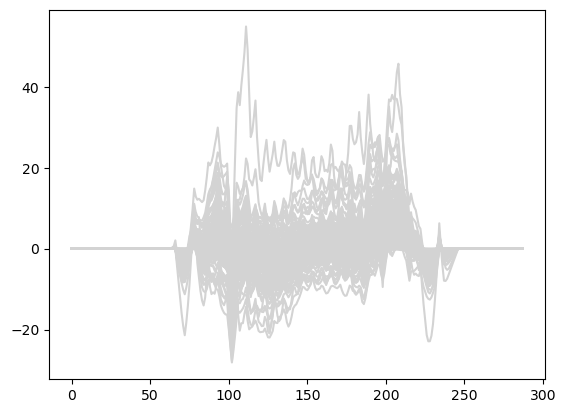

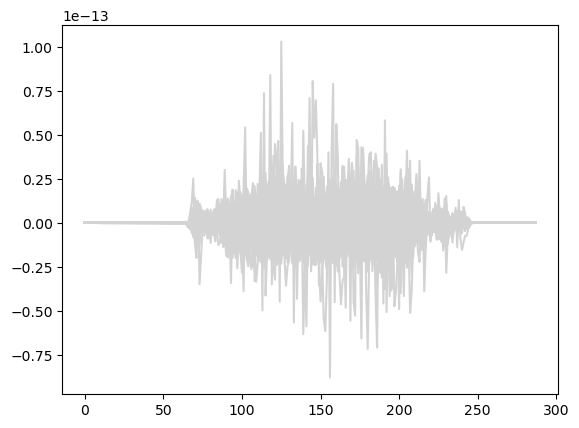

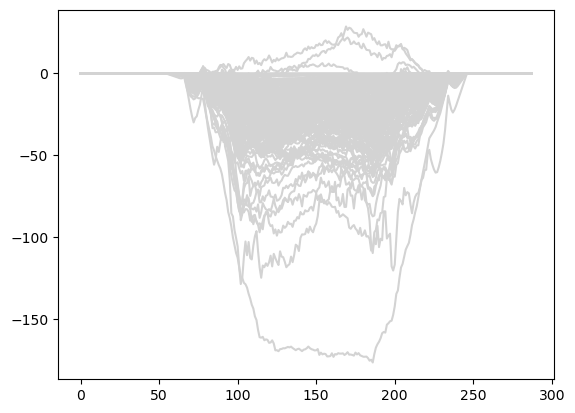

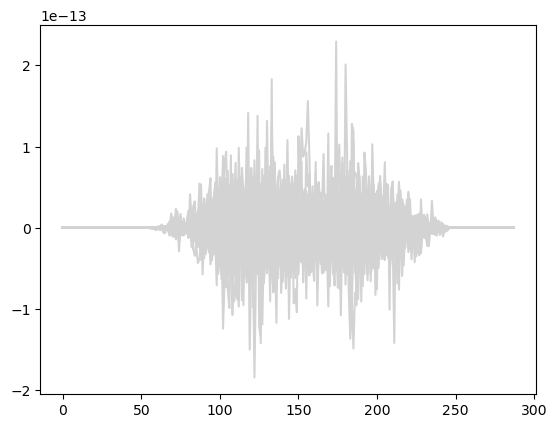

In [75]:
T = 288
# Load 2017 data as training set
with open(path_to_data + f"/linear_preprocessed_{resource}_2017.pkl", 'rb') as f:
    _data = pkl.load(f)

assets_tr_ = _data["assets"]
F_tr_      = _data["observations"]
E_tr_      = _data["forecasts"]
#print(assets_tr_.shape, F_tr_.shape, E_tr_.shape)

# Reshape to day x interval x asset format
F_tr_ = F_tr_.reshape(int(F_tr_.shape[0]/T), T, F_tr_.shape[1])
E_tr_ = E_tr_.reshape(int(E_tr_.shape[0]/T), T, E_tr_.shape[1])
#print(F_tr_.shape, E_tr_.shape)

plt.figure()
plt.plot(np.mean(F_tr_ - E_tr_, axis = 0), c = 'lightgray')
plt.show()

# Unbias training set
B_tr_ = np.mean(F_tr_ - E_tr_, axis = 0)
for i in range(E_tr_.shape[-1]):
    E_tr_[:, :, i] += B_tr_[:, i]

plt.figure()
plt.plot(np.mean(F_tr_ - E_tr_, axis = 0), c = 'lightgray')
plt.show()

# Load 2018 data as testing set
with open(path_to_data + f"/linear_preprocessed_{resource}_2018.pkl", 'rb') as f:
    _data = pkl.load(f)

assets_ts_ = _data["assets"]
F_ts_      = _data["observations"]
E_ts_      = _data["forecasts"]
#print(assets_ts_.shape, F_ts_.shape, E_ts_.shape)

# Reshape to day x interval x asset format
F_ts_ = F_ts_.reshape(int(F_ts_.shape[0]/T), T, F_ts_.shape[1])
E_ts_ = E_ts_.reshape(int(E_ts_.shape[0]/T), T, E_ts_.shape[1])
#print(F_ts_.shape, E_ts_.shape)

# Short testing set with training set order
order  = {v: i for i, v in enumerate(assets_tr_)}
idx_   = np.argsort([order[x] for x in assets_ts_])
F_ts_  = F_ts_[:, :, idx_]
E_ts_  = E_ts_[:, :, idx_]
#print(F_ts_.shape, E_ts_.shape)

plt.figure()
plt.plot(np.mean(F_ts_ - E_ts_, axis = 0), c = 'lightgray')
plt.show()

# Unbias testing set
B_ts_ = np.mean(F_ts_ - E_ts_, axis = 0)
for i in range(E_ts_.shape[-1]):
    E_ts_[:, :, i] += B_ts_[:, i]

plt.figure()
plt.plot(np.mean(F_ts_ - E_ts_, axis = 0), c = 'lightgray')
plt.show()

# From generation to capacity factor
p_tr_ = np.max(np.max(F_tr_, axis = 0), axis = 0)
p_ts_ = np.max(np.max(F_ts_, axis = 0), axis = 0)
# print(p_tr_.shape, p_ts_.shape)

F_tr_ /= np.tile(p_tr_, (F_tr_.shape[0], F_tr_.shape[1], 1))
F_ts_ /= np.tile(p_ts_, (F_ts_.shape[0], F_ts_.shape[1], 1))
E_tr_ /= np.tile(p_tr_, (E_tr_.shape[0], E_tr_.shape[1], 1))
E_ts_ /= np.tile(p_ts_, (E_ts_.shape[0], E_ts_.shape[1], 1))

# No possble a capacity factor is larger than 1 or smaller than 0
F_tr_[F_tr_ > 1.] = 1.
F_ts_[F_ts_ > 1.] = 1.
E_tr_[E_tr_ > 1.] = 1.
E_ts_[E_ts_ > 1.] = 1.

F_tr_[F_tr_ < 0.] = 0.
F_ts_[F_ts_ < 0.] = 0.
E_tr_[E_tr_ < 0.] = 0.
E_ts_[E_ts_ < 0.] = 0.

F_tr_ /= F_tr_.max()
F_ts_ /= F_ts_.max()
E_tr_ /= E_tr_.max()
E_ts_ /= E_ts_.max()

# Format training set from day x interval x asset to [day * asset] x interval
E_ts_lin_ = E_ts_.copy()
E_tr_lin_ = np.concatenate([E_tr_[..., k] for k in range(E_tr_.shape[2])], axis = 0)
#print(E_tr_lin_.shape, E_ts_lin_.shape)

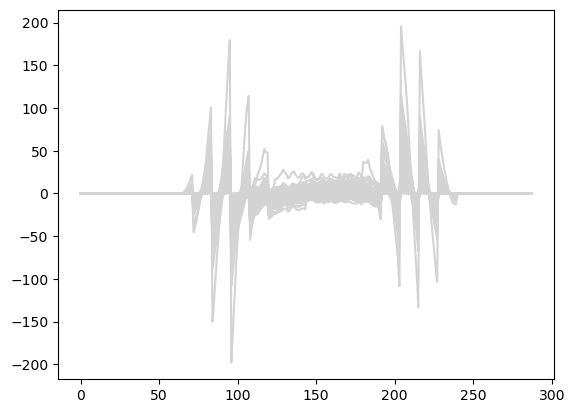

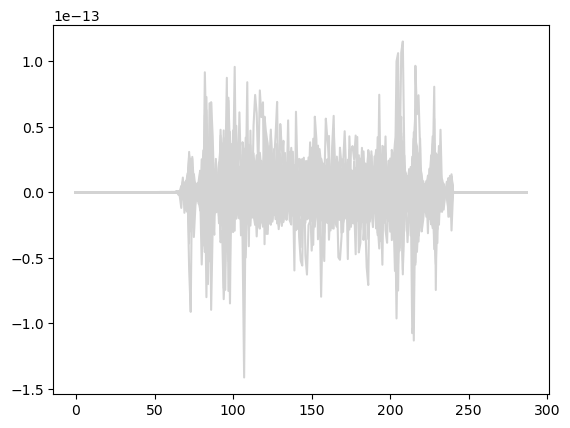

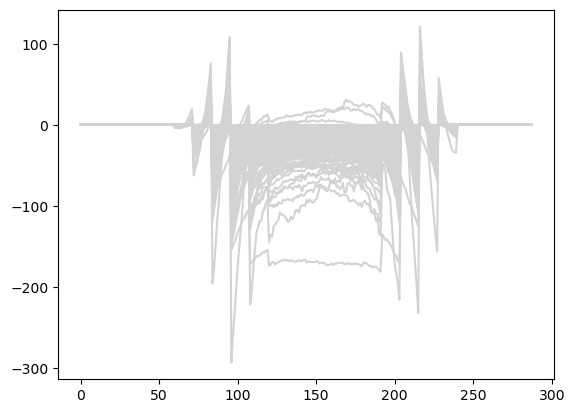

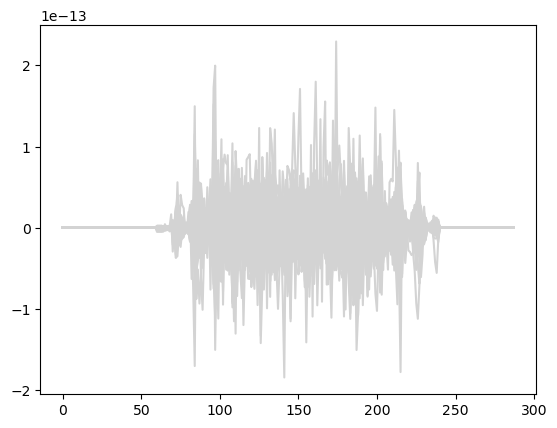

In [76]:
# Load 2017 data as training set
with open(path_to_data + f"/preprocessed_{resource}_2017.pkl", 'rb') as f:
    _data = pkl.load(f)

assets_tr_ = _data["assets"]
x_tr_      = _data["locations"]
dates_tr_  = _data["dates"]
F_tr_      = _data["observations"]
E_tr_      = _data["forecasts"]
#print(assets_tr_.shape, x_tr_.shape, dates_tr_.shape, F_tr_.shape, E_tr_.shape)

# Reshape to day x interval x asset format
F_tr_ = F_tr_.reshape(int(F_tr_.shape[0]/T), T, F_tr_.shape[1])
E_tr_ = E_tr_.reshape(int(E_tr_.shape[0]/T), T, E_tr_.shape[1])
T_tr_ = dates_tr_.reshape(int(dates_tr_.shape[0]/T), T)
#print(F_tr_.shape, E_tr_.shape, T_tr_.shape)

plt.figure()
plt.plot(np.mean(F_tr_ - E_tr_, axis = 0), c = 'lightgray')
plt.show()

# Unbias training set
B_tr_ = np.mean(F_tr_ - E_tr_, axis = 0)
for i in range(E_tr_.shape[-1]):
    E_tr_[:, :, i] += B_tr_[:, i]

plt.figure()
plt.plot(np.mean(F_tr_ - E_tr_, axis = 0), c = 'lightgray')
plt.show()

# Load 2018 data as testing set
with open(path_to_data + f"/preprocessed_{resource}_2018.pkl", 'rb') as f:
    _data = pkl.load(f)

assets_ts_ = _data["assets"]
x_ts_      = _data["locations"]
dates_ts_  = _data["dates"]
F_ts_      = _data["observations"]
E_ts_      = _data["forecasts"]
#print(assets_ts_.shape, x_ts_.shape, dates_ts_.shape, F_ts_.shape, E_ts_.shape)

# Reshape to day x interval x asset format
F_ts_ = F_ts_.reshape(int(F_ts_.shape[0]/T), T, F_ts_.shape[1])
E_ts_ = E_ts_.reshape(int(E_ts_.shape[0]/T), T, E_ts_.shape[1])
T_ts_ = dates_ts_.reshape(int(dates_ts_.shape[0]/T), T)
#print(F_ts_.shape, E_ts_.shape, T_ts_.shape)

dt_ = np.array([t * 5 for t in range(T)])
dx_ = pd.to_datetime(pd.DataFrame({"time": dt_}).time, unit = "m").dt.strftime("%H:%M").to_numpy()
#print(dt_.shape, dx_.shape)

# Short testing set with training set order
order      = {v: i for i, v in enumerate(assets_tr_)}
idx_       = np.argsort([order[x] for x in assets_ts_])
assets_ts_ = assets_ts_[idx_]
x_ts_      = x_ts_[idx_]
F_ts_      = F_ts_[:, :, idx_]
E_ts_      = E_ts_[:, :, idx_]
#print(F_ts_.shape, E_ts_.shape, T_ts_.shape)

plt.figure()
plt.plot(np.mean(F_ts_ - E_ts_, axis = 0), c = 'lightgray')
plt.show()

# Unbias testing set
B_ts_ = np.mean(F_ts_ - E_ts_, axis = 0)
for i in range(E_ts_.shape[-1]):
    E_ts_[:, :, i] += B_ts_[:, i]

plt.figure()
plt.plot(np.mean(F_ts_ - E_ts_, axis = 0), c = 'lightgray')
plt.show()

    
# From generation to capacity factor
p_tr_ = np.max(np.max(F_tr_, axis = 0), axis = 0)
p_ts_ = np.max(np.max(F_ts_, axis = 0), axis = 0)
#print(p_tr_.shape, p_ts_.shape)

F_tr_ /= np.tile(p_tr_, (F_tr_.shape[0], F_tr_.shape[1], 1))
F_ts_ /= np.tile(p_ts_, (F_ts_.shape[0], F_ts_.shape[1], 1))
E_tr_ /= np.tile(p_tr_, (E_tr_.shape[0], E_tr_.shape[1], 1))
E_ts_ /= np.tile(p_ts_, (E_ts_.shape[0], E_ts_.shape[1], 1))

# No possble a capacity factor is larger than 1 or smaller than 0
F_tr_[F_tr_ > 1.] = 1.
F_ts_[F_ts_ > 1.] = 1.
E_tr_[E_tr_ > 1.] = 1.
E_ts_[E_ts_ > 1.] = 1.

F_tr_[F_tr_ < 0.] = 0.
F_ts_[F_ts_ < 0.] = 0.
E_tr_[E_tr_ < 0.] = 0.
E_ts_[E_ts_ < 0.] = 0.

F_tr_ /= F_tr_.max()
F_ts_ /= F_ts_.max()
E_tr_ /= E_tr_.max()
E_ts_ /= E_ts_.max()

# Format training set from day x interval x asset to [day * asset] x interval
T_tr_ = np.concatenate([T_tr_ for k in range(assets_tr_.shape[0])], axis = 0)
assets_tr_ = np.concatenate([np.tile(assets_tr_[k], (F_tr_.shape[0], 1)) for k in range(assets_tr_.shape[0])], axis = 0)
x_tr_ = np.concatenate([np.tile(x_tr_[k, :], (F_tr_.shape[0], 1)) for k in range(x_tr_.shape[0])], axis = 0)
F_tr_ = np.concatenate([F_tr_[..., k] for k in range(F_tr_.shape[2])], axis = 0)
E_tr_ = np.concatenate([E_tr_[..., k] for k in range(E_tr_.shape[2])], axis = 0)
#print(x_tr_.shape, assets_tr_.shape, F_tr_.shape, E_tr_.shape, T_tr_.shape)
#print(x_ts_.shape, assets_ts_.shape, F_ts_.shape, E_ts_.shape, T_ts_.shape)

t_tr_ = np.array([datetime.datetime.strptime(t_tr, "%Y-%m-%d %H:%M:%S").timetuple().tm_yday for t_tr in T_tr_[:, 0]]) - 1
t_ts_ = np.array([datetime.datetime.strptime(t_ts, "%Y-%m-%d %H:%M:%S").timetuple().tm_yday for t_ts in T_ts_[:, 0]]) - 1
#print(t_tr_.shape, t_ts_.shape)

In [77]:
def _plot_PIT(_ax, u_, bins=10, title="PIT Histogram"):
    """
    Make a PIT histogram with a Uniform(0,1) reference line.
    Uses matplotlib, one chart, no explicit colors.
    """

    # histogram as density so the uniform reference is y=1
    counts_, bins, patches = _ax.hist(u_, 
                                     bins=bins, 
                                     range=(0.0, 1.0), 
                                     density=True, 
                                     edgecolor='black', 
                                     alpha = 0.5)   

    _ax.axhline(1.0, linestyle='--', color='red')
    _ax.set_xlim(0, 1)
    _ax.set_ylim(0, )

    _ax.set_xlabel("u = F̂(y_obs)")
    _ax.set_ylabel("Density")
    _ax.set_title(title)

def _KS(pit_):
    pit_ = np.asarray(pit_, dtype=float)
    pit_ = pit_[np.isfinite(pit_)]
    pit_ = np.clip(pit_, 0.0, 1.0)
    return stats.kstest(pit_, 'uniform').statistic

                     120       144       168
parameter                                   
forget_rate_f     0.0625    0.0625    0.0625
forget_rate_e     0.2500    0.2500    0.2500
lookup_rate      64.0000  128.0000  256.0000
length_scale_f    0.0500    0.0500    0.0250
length_scale_e    0.5000    0.5000    0.5000
trust_rate        0.4000    0.4000    0.4000
nu               10.0000   10.0000   10.0000
xi                0.8000    0.8000    0.8000
gamma            20.0000   20.0000   30.0000
kappa_min       110.0000  110.0000  100.0000
kappa_max       125.0000  125.0000  125.0000
p_fusion          0.3000    0.3000    0.3000


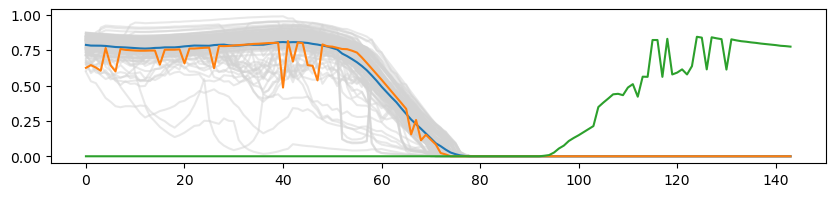

In [78]:
# Validation set identifier
hyper_ = pd.read_csv(path_to_param + f'/{resource}-{method}-hyper.csv')
hyper_ = hyper_.set_index("parameter")
hyper_.columns = hyper_.columns.astype(int)
print(hyper_)

asset = 20
time = 144
day = 30

# Get functional predictors for a given test
f_hat_ = F_ts_[day, time:, asset]
e_lin_ = E_ts_lin_[day, :, asset]
f_ = F_ts_[day, :time, asset]
e_ = E_ts_[day, :, asset]
x_ts = x_ts_[asset, :]
t_ts = t_ts_[day]

# Filter solar hours with loading solar set
# idx_days_  = np.absolute(t_tr_ - day) < 28
# idx_hours_ = np.mean(F_tr_[idx_days_, :], axis = 0) > .25

idx_days_  = np.absolute(t_tr_ - day) < 7
idx_hours_ = (np.sum(F_tr_[idx_days_, :], axis = 0) + np.sum(E_tr_[idx_days_, :], axis = 0)) > 1.

_meta, M_ = _fknn_forecast_dynamic_update(F_tr_, E_tr_lin_, x_tr_, t_tr_, dt_, f_, e_lin_, x_ts, t_ts,
                                          forget_rate_f = hyper_.loc['forget_rate_f'][time],
                                          forget_rate_e = hyper_.loc['forget_rate_e'][time],
                                          length_scale_f = hyper_.loc['length_scale_f'][time],
                                          length_scale_e = hyper_.loc['length_scale_e'][time],
                                          lookup_rate = hyper_.loc['lookup_rate'][time],
                                          trust_rate = hyper_.loc['trust_rate'][time],
                                          nu = hyper_.loc['nu'][time],
                                          gamma = hyper_.loc['gamma'][time],
                                          xi = hyper_.loc['xi'][time],
                                          kappa_min = hyper_.loc['kappa_min'][time],
                                          kappa_max = hyper_.loc['kappa_max'][time], 
                                          p_fusion = hyper_.loc['trust_rate'][time],
                                          idx_hours_ = idx_hours_)

# print(M_.shape)
# print(_meta.keys())
# print(_meta['w'][_meta['idx_spatial']].shape)

plt.figure(figsize=(10, 2))
plt.plot(M_.T, color = 'lightgray', alpha = 0.5)
plt.plot(_meta['focal_curve'])
plt.plot(f_hat_)
plt.plot(f_)
plt.show()

In [79]:
def _run_ffc(day, asset):

    file_name = f'{asset}-{day}-{time}'
    #print(f'Processing file {file_name}...')

    # Get functional predictors for a given test
    f_     = F_ts_[day, :time, asset]
    e_lin_ = E_ts_lin_[day, :, asset]
    x_ts   = x_ts_[asset, :]
    t_ts   = t_ts_[day]
    f_hat_ = F_ts_[day, time:, asset]

    # Filter solar hours with loading solar set
    #idx_days_  = np.absolute(t_tr_ - day) < 28
    #idx_hours_ = np.mean(F_tr_[idx_days_, :], axis = 0) > .25

    idx_days_  = np.absolute(t_tr_ - day) < 7
    idx_hours_ = (np.sum(F_tr_[idx_days_, :], axis = 0) + np.sum(E_tr_[idx_days_, :], axis = 0)) > 1.
    
    _meta, M_ = _fknn_forecast_dynamic_update(F_tr_, E_tr_lin_, x_tr_, t_tr_, dt_, f_, e_lin_, x_ts, t_ts,
                                              forget_rate_f = hyper_.loc['forget_rate_f'][time],
                                              forget_rate_e = hyper_.loc['forget_rate_e'][time],
                                              length_scale_f = hyper_.loc['length_scale_f'][time],
                                              length_scale_e = hyper_.loc['length_scale_e'][time],
                                              lookup_rate = hyper_.loc['lookup_rate'][time],
                                              trust_rate = hyper_.loc['trust_rate'][time],
                                              gamma = hyper_.loc['gamma'][time],
                                              xi = hyper_.loc['xi'][time],
                                              nu = hyper_.loc['nu'][time],
                                              kappa_min = hyper_.loc['kappa_min'][time],
                                              kappa_max = hyper_.loc['kappa_max'][time], 
                                              p_fusion = hyper_.loc['p_fusion'][time], 
                                              idx_hours_ = idx_hours_)

    #M_p_, f_p_ = _bias_correction(M_, _meta['focal_curve'], bias_, time, scale = 0.5)
    M_p_ = M_ 
    f_p_ = _meta['focal_curve'].copy()

    return [M_p_, f_hat_, f_p_, file_name]

def _run_parallel(n_workers = 32, 
                  assets_ = range(5), 
                  indices_ = range(363)):

    M_     = []
    f_hat_ = []
    focal_ = []
    date_ = []
    for asset in assets_:
        with mp.Pool(processes = n_workers) as pool:
            worker = partial(_run_ffc, asset=asset)
            results_ = pool.map(worker, indices_)
        M_ += [result[0] for result in results_]
        f_hat_ += [result[1] for result in results_]
        focal_ += [result[2] for result in results_]
        date_ += [result[3] for result in results_]

    print(len(M_), len(f_hat_), len(focal_), len(date_))
    return M_, f_hat_, focal_, date_

In [80]:
# Validation set identifier
hyper_ = pd.read_csv(path_to_param + f'/{resource}-{method}-hyper.csv')
hyper_ = hyper_.set_index("parameter")
hyper_.columns = hyper_.columns.astype(int)
print(hyper_)

time = 120

M_, f_hat_, focal_, date_ = _run_parallel(n_workers = 72, 
                                          assets_ = range(0, 20, 1), 
                                          indices_ = range(363))

                     120       144       168
parameter                                   
forget_rate_f     0.0625    0.0625    0.0625
forget_rate_e     0.2500    0.2500    0.2500
lookup_rate      64.0000  128.0000  256.0000
length_scale_f    0.0500    0.0500    0.0250
length_scale_e    0.5000    0.5000    0.5000
trust_rate        0.4000    0.4000    0.4000
nu               10.0000   10.0000   10.0000
xi                0.8000    0.8000    0.8000
gamma            20.0000   20.0000   30.0000
kappa_min       110.0000  110.0000  100.0000
kappa_max       125.0000  125.0000  125.0000
p_fusion          0.3000    0.3000    0.3000
7260 7260 7260 7260


In [81]:
U_ = []
B_ = []
S_ = []
for i in range(len(M_)):
    B_ += [f_hat_[i] - focal_[i]]
    U_ += [_empirical_PIT(f_hat_[i], M_[i].T, seed = 1234)]
    S_ += [np.std(M_[i], axis = 0).mean()]
U_ = np.array(U_)
B_ = np.array(B_)
print(U_.shape, B_.shape)

df_1_ = pd.DataFrame({"date": date_, "std": S_})
df_1_[['asset', 'day', 'interval']] = df_1_['date'].str.split('-', expand=True)
df_1_.drop(columns = ['date'], inplace = True)
print(df_1_)

(7260, 168) (7260, 168)
           std asset  day interval
0     0.091812     0    0      120
1     0.096691     0    1      120
2     0.100265     0    2      120
3     0.103880     0    3      120
4     0.097123     0    4      120
...        ...   ...  ...      ...
7255  0.061952    19  358      120
7256  0.059486    19  359      120
7257  0.056293    19  360      120
7258  0.060083    19  361      120
7259  0.113293    19  362      120

[7260 rows x 4 columns]


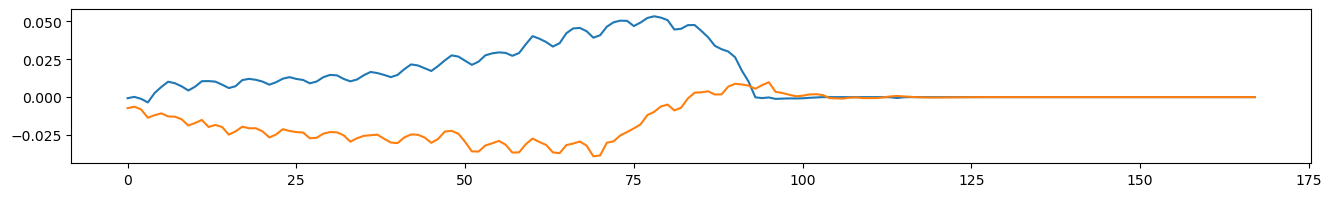

0.053444370776114164 0.03910400992401962


In [82]:
plt.figure(figsize=(16, 2))
plt.plot(np.median(B_, axis = 0))
plt.plot(np.mean(B_, axis = 0))
plt.show()

print(np.absolute(np.median(B_, axis = 0)).max(), np.absolute(np.mean(B_, axis = 0)).max())

KS for lead time 1h: 0.06372439736980484
KS for lead time 2h: 0.10904074228934224
KS for lead time 3h: 0.05451790633608811
KS for lead time 4h: 0.09383062410985066


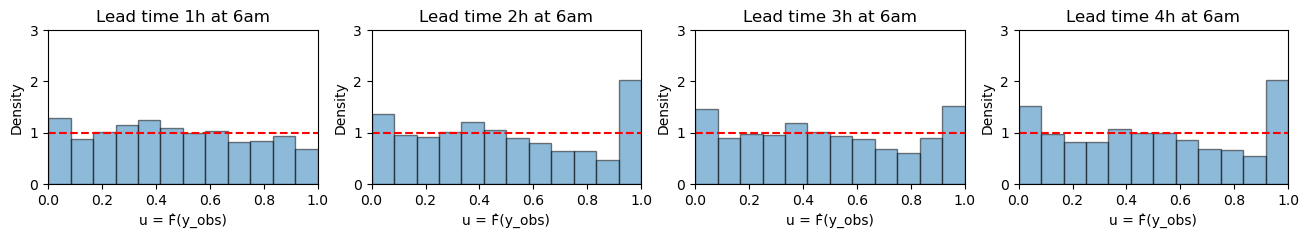

KS over lead times: 0.32111367010508585


In [83]:
lead = 1
bins = 12
fig, ax = plt.subplots(1, 4, figsize=(16, 2))  
ttl = 0.
for i in range(4):
    _plot_PIT(ax[i], U_[:, (i + lead)*12], 
              bins = bins, 
              title = f'Lead time {i + lead}h at 6am')
    ax[i].set_ylim(0, 3)
    
    KS = _KS(U_[:, (i + lead)*12])
    ttl += KS
    
    print(f'KS for lead time {i + lead}h: {KS}')

plt.show()

print(f'KS over lead times: {ttl}')

KS for lead time 0h: 0.061689631191436334
KS for lead time 1h: 0.04064003673094585
KS for lead time 2h: 0.05362748995165745
KS for lead time 3h: 0.05061616161616156
KS for lead time 4h: 0.05589010643863157
KS for lead time 5h: 0.06892154491028102


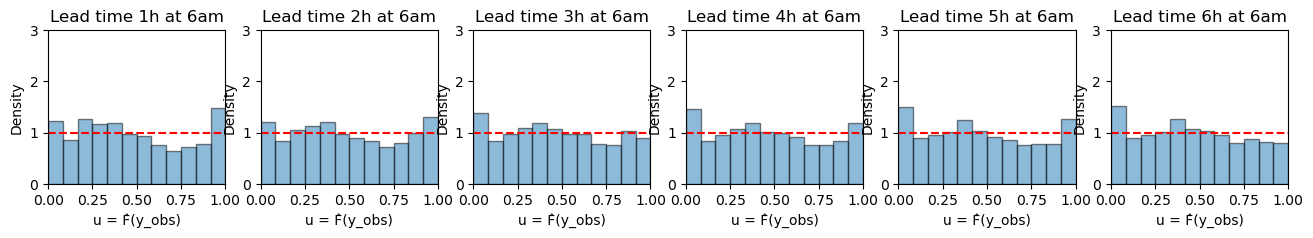

KS over lead times: 0.3313849708391138


In [84]:
bins = 12
lead = 0
n_intervals = 6

fig, ax = plt.subplots(1, n_intervals, figsize=(16, 2))  
ttl = 0.
for i in range(n_intervals):
    _plot_PIT(ax[i], U_[:, (i + lead)*6:(i + lead + 1)*6].flatten(), 
            bins = bins, 
            title = f'Lead time {i + 1}h at 6am')
    ax[i].set_ylim(0, 3)
    
    KS = _KS(U_[:, (i + lead)*6:(i + lead + 1)*6].flatten())
    
    ttl += KS
    print(f'KS for lead time {i + lead}h: {KS}')
plt.show()

print(f'KS over lead times: {ttl}')

In [85]:
# Validation set identifier
hyper_ = pd.read_csv(path_to_param + f'/{resource}-{method}-hyper.csv')
hyper_ = hyper_.set_index("parameter")
hyper_.columns = hyper_.columns.astype(int)
print(hyper_)

time = 144

M_, f_hat_, focal_, date_ = _run_parallel(n_workers = 72, 
                                          assets_ = range(0, 20, 1), 
                                          indices_ = range(363))

                     120       144       168
parameter                                   
forget_rate_f     0.0625    0.0625    0.0625
forget_rate_e     0.2500    0.2500    0.2500
lookup_rate      64.0000  128.0000  256.0000
length_scale_f    0.0500    0.0500    0.0250
length_scale_e    0.5000    0.5000    0.5000
trust_rate        0.4000    0.4000    0.4000
nu               10.0000   10.0000   10.0000
xi                0.8000    0.8000    0.8000
gamma            20.0000   20.0000   30.0000
kappa_min       110.0000  110.0000  100.0000
kappa_max       125.0000  125.0000  125.0000
p_fusion          0.3000    0.3000    0.3000
7260 7260 7260 7260


In [86]:
U_ = []
B_ = []
S_ = []
for i in range(len(M_)):
    B_ += [f_hat_[i] - focal_[i]]
    U_ += [_empirical_PIT(f_hat_[i], M_[i].T, seed = 1234)]
    S_ += [np.std(M_[i], axis = 0).mean()]
U_ = np.array(U_)
B_ = np.array(B_)
print(U_.shape, B_.shape)

df_2_ = pd.DataFrame({"date": date_, "std": S_})
df_2_[['asset', 'day', 'interval']] = df_2_['date'].str.split('-', expand=True)
df_2_.drop(columns = ['date'], inplace = True)
print(df_2_)

(7260, 144) (7260, 144)
           std asset  day interval
0     0.047212     0    0      144
1     0.085007     0    1      144
2     0.053046     0    2      144
3     0.066697     0    3      144
4     0.056510     0    4      144
...        ...   ...  ...      ...
7255  0.057282    19  358      144
7256  0.086908    19  359      144
7257  0.057410    19  360      144
7258  0.056658    19  361      144
7259  0.090743    19  362      144

[7260 rows x 4 columns]


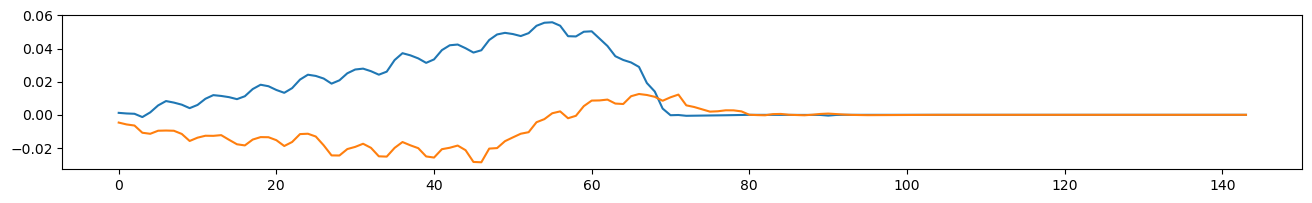

0.05585209212131348 0.028631279577375678


In [87]:
plt.figure(figsize=(16, 2))
plt.plot(np.median(B_, axis = 0))
plt.plot(np.mean(B_, axis = 0))
plt.show()

print(np.absolute(np.median(B_, axis = 0)).max(), np.absolute(np.mean(B_, axis = 0)).max())

KS for lead time 1h: 0.07211019283746556
KS for lead time 2h: 0.10905268423187842


KS for lead time 3h: 0.08189849779810265
KS for lead time 4h: 0.06957345422698968


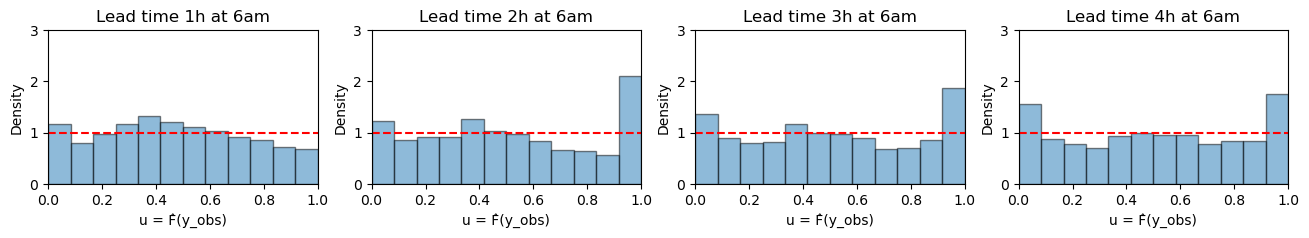

KS over lead times: 0.3326348290944363


In [88]:
lead = 1
bins = 12
ttl = 0.

fig, ax = plt.subplots(1, 4, figsize=(16, 2))  

for i in range(4):
    _plot_PIT(ax[i], U_[:, (i + lead)*12], 
              bins = bins, 
              title = f'Lead time {i + lead}h at 6am')
    ax[i].set_ylim(0, 3)
    
    KS = _KS(U_[:, (i + lead)*12])
    ttl += KS
    
    print(f'KS for lead time {i + lead}h: {KS}')

plt.show()

print(f'KS over lead times: {ttl}')

KS for lead time 1h: 0.05742424242424238
KS for lead time 2h: 0.05949494949494949
KS for lead time 3h: 0.04201744719926537
KS for lead time 4h: 0.03619763043084956
KS for lead time 5h: 0.04474542284416694
KS for lead time 6h: 0.04216712580348944


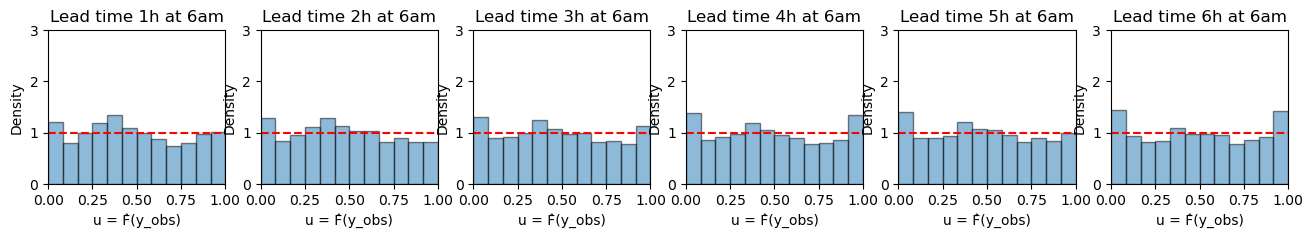

KS over lead times: 0.2820468181969632


In [89]:
lead = 1
bins = 12
ttl = 0.

n_intervals = 6

fig, ax = plt.subplots(1, n_intervals, figsize=(16, 2))  

for i in range(n_intervals):
    _plot_PIT(ax[i], U_[:, (i + lead)*6:(i + lead + 1)*6].flatten(), 
            bins = bins, 
            title = f'Lead time {i + lead}h at 6am')
    ax[i].set_ylim(0, 3)
    
    KS = _KS(U_[:, (i + lead)*6:(i + lead + 1)*6].flatten())
    ttl += KS

    print(f'KS for lead time {i + lead}h: {KS}')
    
plt.show()

print(f'KS over lead times: {ttl}')

In [90]:
# Validation set identifier
hyper_ = pd.read_csv(path_to_param + f'/{resource}-{method}-hyper.csv')
hyper_ = hyper_.set_index("parameter")
hyper_.columns = hyper_.columns.astype(int)
print(hyper_)

time = 168

M_, f_hat_, focal_, date_ = _run_parallel(n_workers = 72, 
                                          assets_ = range(0, 20, 1), 
                                          indices_ = range(363)) 

                     120       144       168
parameter                                   
forget_rate_f     0.0625    0.0625    0.0625
forget_rate_e     0.2500    0.2500    0.2500
lookup_rate      64.0000  128.0000  256.0000
length_scale_f    0.0500    0.0500    0.0250
length_scale_e    0.5000    0.5000    0.5000
trust_rate        0.4000    0.4000    0.4000
nu               10.0000   10.0000   10.0000
xi                0.8000    0.8000    0.8000
gamma            20.0000   20.0000   30.0000
kappa_min       110.0000  110.0000  100.0000
kappa_max       125.0000  125.0000  125.0000
p_fusion          0.3000    0.3000    0.3000
7260 7260 7260 7260


In [91]:
U_ = []
B_ = []
S_ = []
for i in range(len(M_)):
    B_ += [f_hat_[i] - focal_[i]]
    U_ += [_empirical_PIT(f_hat_[i], M_[i].T, seed = 1234)]
    S_ += [np.std(M_[i], axis = 0).mean()]
U_ = np.array(U_)
B_ = np.array(B_)
S_ = np.array(S_)
print(U_.shape, B_.shape, S_.shape)

df_3_ = pd.DataFrame({"date": date_, "std": S_})
df_3_[['asset', 'day', 'interval']] = df_3_['date'].str.split('-', expand=True)
df_3_.drop(columns = ['date'], inplace = True)
print(df_3_)

(7260, 120) (7260, 120) (7260,)
           std asset  day interval
0     0.038303     0    0      168
1     0.043074     0    1      168
2     0.038071     0    2      168
3     0.045261     0    3      168
4     0.033543     0    4      168
...        ...   ...  ...      ...
7255  0.046236    19  358      168
7256  0.041939    19  359      168
7257  0.044665    19  360      168
7258  0.050205    19  361      168
7259  0.060148    19  362      168

[7260 rows x 4 columns]


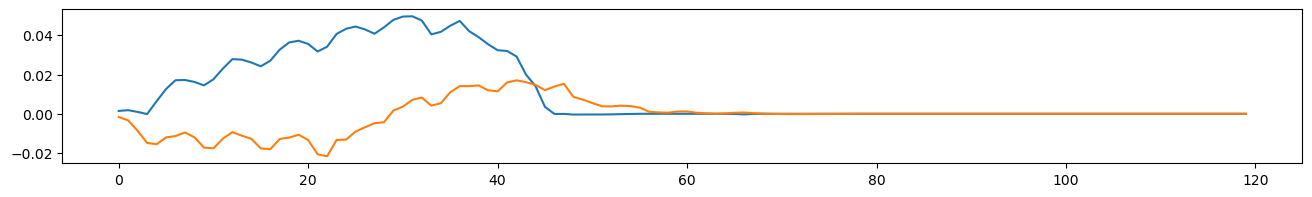

0.04965466214074432 0.021636366622764525


In [92]:
plt.figure(figsize=(16, 2))
plt.plot(np.median(B_, axis = 0))
plt.plot(np.mean(B_, axis = 0))
plt.show()

print(np.absolute(np.median(B_, axis = 0)).max(), np.absolute(np.mean(B_, axis = 0)).max())

KS for lead time 1h: 0.06198347107438007
KS for lead time 2h: 0.06683019626380637
KS for lead time 3h: 0.09797245179063363


KS for lead time 4h: 0.1260889939062055


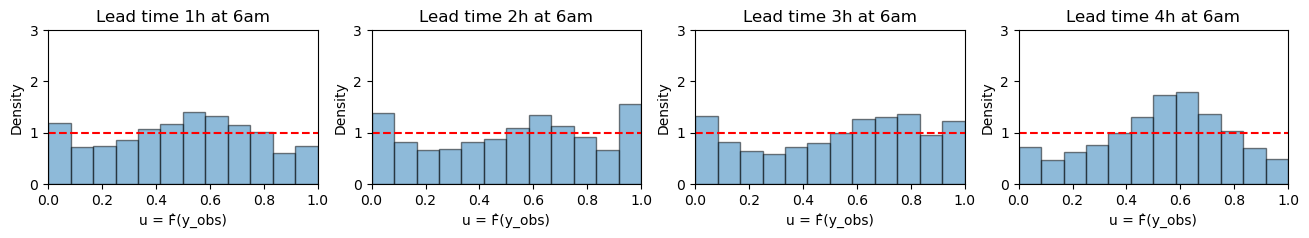

KS over lead times: 0.3528751130350256


In [93]:
lead = 1
bins = 12
ttl = 0.

fig, ax = plt.subplots(1, 4, figsize=(16, 2))  

for i in range(4):
    _plot_PIT(ax[i], U_[:, (i + lead)*12], 
              bins = bins, 
              title = f'Lead time {i + lead}h at 6am')
    
    ax[i].set_ylim(0, 3)
    
    KS = _KS(U_[:, (i + lead)*12])
    ttl += KS

    print(f'KS for lead time {i + lead}h: {KS}')

plt.show()

print(f'KS over lead times: {ttl}')

KS for lead time 1h: 0.03880997096785488
KS for lead time 2h: 0.035674931129476506
KS for lead time 3h: 0.04072176308539949
KS for lead time 4h: 0.06453206889195112
KS for lead time 5h: 0.07662075298438942
KS for lead time 6h: 0.09032782369146009


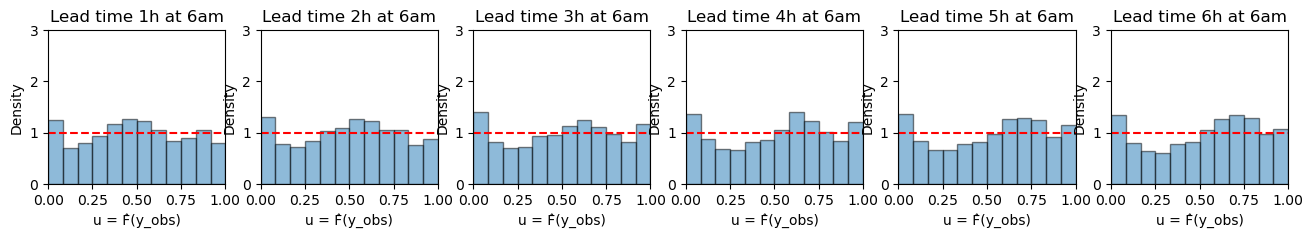

KS over lead times: 0.3466873107505315


In [94]:
lead = 1
bins = 12
ttl = 0.
n_intervals = 6

fig, ax = plt.subplots(1, n_intervals, figsize=(16, 2))  

for i in range(n_intervals):
    _plot_PIT(ax[i], U_[:, (i + lead)*6:(i + lead + 1)*6].flatten(), 
            bins = bins, 
            title = f'Lead time {i + lead}h at 6am')
    ax[i].set_ylim(0, 3)
    
    KS = _KS(U_[:, (i + lead)*6:(i + lead + 1)*6].flatten())
    ttl += KS

    print(f'KS for lead time {i + lead}h: {KS}')

plt.show()

print(f'KS over lead times: {ttl}')

In [95]:
df_ = pd.concat([df_1_, df_2_, df_3_], axis = 0)    
print(df_.shape)

df_.to_csv(path_to_validation + f'/{resource}_{method}_dispersion-1.csv', index = False)

(21780, 4)
